# EN3160 - Image Processing Assignment 1

**Name:** Hasith Nettikumara  
**Index Number:** 230436X  

This notebook contains the implementations and results for Assignment 1 on intensity transformations and neighborhood filtering.

In [1]:
%pip install matplotlib opencv-python numpy


[notice] A new release of pip is available: 24.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# Folder containing the assignment images
IMAGE_DIR = Path("images")

# Check that the folder exists
print("Image directory exists:", IMAGE_DIR.exists())

Image directory exists: True


In [4]:
def show_image(image, title="", cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)

    if image.ndim == 3:
        # OpenCV loads color images in BGR format
        image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        plt.imshow(image_rgb)
    else:
        plt.imshow(image, cmap=cmap if cmap else "gray")

    plt.title(title)
    plt.axis("off")
    plt.show()

## Question 1 - Piecewise Linear Intensity Transformation

A piecewise linear intensity transformation is applied to the given grayscale image using a set of specified breakpoints. Linear interpolation is used to determine the output intensity values between consecutive breakpoints.

In [5]:
print("Available assignment images:")

for q1_available_image_path in IMAGE_DIR.iterdir():
    print(q1_available_image_path.name)

Available assignment images:
im01.png
im01small.png
im02.png
im02small.png
im03.png
im03small.png
im04.jpg
im04small.jpg
im05.jpg
q1.jpeg
q2.jpeg
shells.tif
WhatsApp Image 2026-09-09 at 20.02.43 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg
WhatsApp Image 2026-09-09 at 20.02.44 (3).jpeg
WhatsApp Image 2026-09-09 at 20.02.441.jpeg


In [6]:
q1_portrait_file = IMAGE_DIR / "q1.jpeg"

q1_portrait_gray = cv.imread(
    str(q1_portrait_file),
    cv.IMREAD_GRAYSCALE
)

if q1_portrait_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 1 image: {q1_portrait_file}"
    )

print("Image shape:", q1_portrait_gray.shape)
print("Image datatype:", q1_portrait_gray.dtype)
print("Minimum intensity:", q1_portrait_gray.min())
print("Maximum intensity:", q1_portrait_gray.max())

Image shape: (810, 720)
Image datatype: uint8
Minimum intensity: 0
Maximum intensity: 255


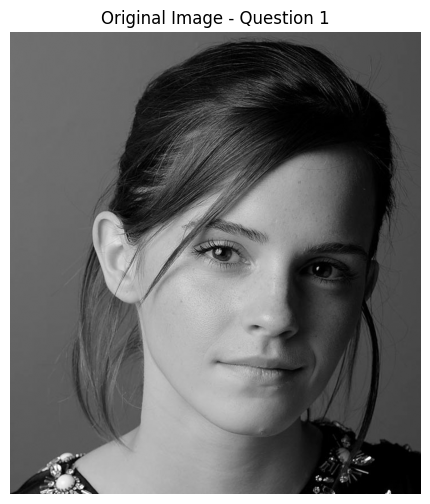

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Image - Question 1")
plt.axis("off")
plt.show()

In [8]:
q1_breakpoints_reference = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_a = np.array([
    [0,   0],
    [40,  30],
    [90,  110],
    [150, 210],
    [210, 245],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_b = np.array([
    [0,   0],
    [50,  25],
    [100, 125],
    [160, 220],
    [220, 250],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_c = np.array([
    [0,   0],
    [40,  30],
    [90,  100],
    [150, 175],
    [210, 225],
    [255, 255]
], dtype=np.float32)


q1_breakpoints_trial_d = np.array([
    [0,   0],
    [40,  28],
    [90,  98],
    [150, 168],
    [210, 222],
    [255, 255]
], dtype=np.float32)

q1_breakpoints_trial_e = np.array([
    [0,   0],
    [40,  32],
    [90,  102],
    [150, 170],
    [210, 220],
    [255, 255]
], dtype=np.float32)


In [9]:
def intensity_transform(im, breakpoints):
    input_levels = breakpoints[:, 0]
    output_levels = breakpoints[:, 1]

    transformed_image = np.interp(
        im.astype(np.float32),
        input_levels,
        output_levels
    )

    transformed_image = np.clip(
        transformed_image,
        0,
        255
    )

    return transformed_image.astype(np.uint8)

In [10]:
q1_output_reference = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_reference
)

q1_output_trial_a = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_a
)

q1_output_trial_b = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_b
)

q1_output_trial_c = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_c
)

q1_output_trial_d = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_d
)

q1_output_trial_e = intensity_transform(
    q1_portrait_gray,
    q1_breakpoints_trial_e
)

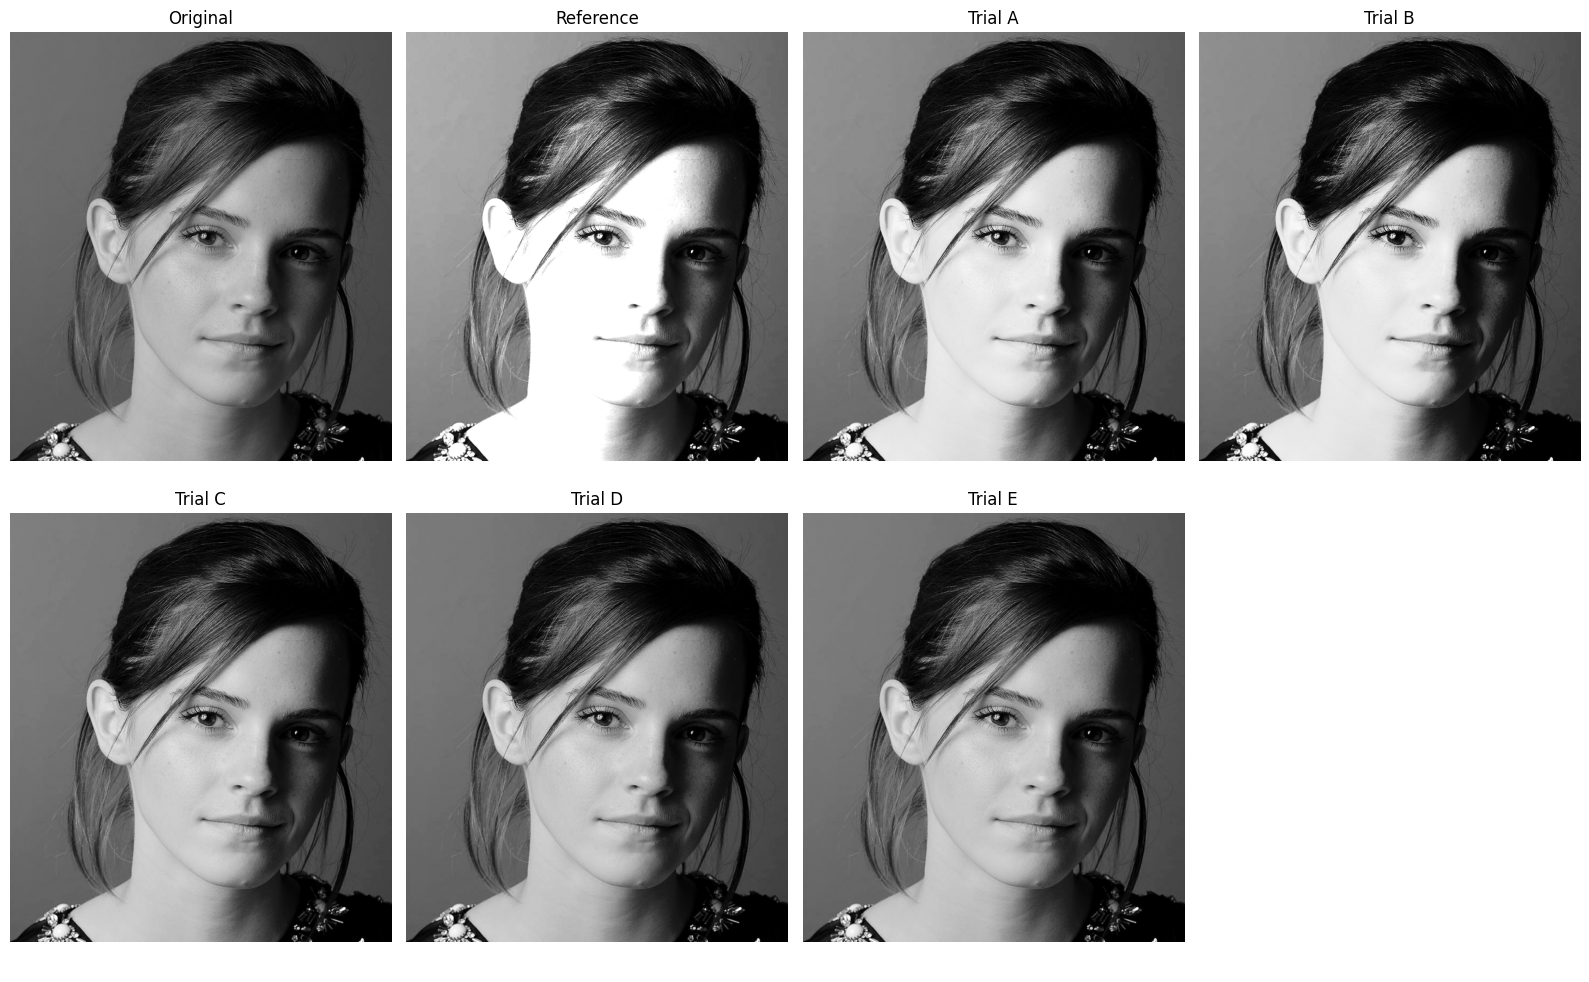

In [14]:
q1_trial_figure, q1_trial_axes = plt.subplots(
    2,
    4,
    figsize=(16, 10)
)

q1_trial_images = [
    q1_portrait_gray,
    q1_output_reference,
    q1_output_trial_a,
    q1_output_trial_b,
    q1_output_trial_c,
    q1_output_trial_d,
    q1_output_trial_e
]

q1_trial_titles = [
    "Original",
    "Reference",
    "Trial A",
    "Trial B",
    "Trial C",
    "Trial D",
    "Trial E"
]

# Flatten the 2x4 axes array so we can index it easily
q1_trial_axes_flat = q1_trial_axes.flatten()

for q1_panel_index in range(len(q1_trial_images)):

    q1_trial_axes_flat[q1_panel_index].imshow(
        q1_trial_images[q1_panel_index],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    q1_trial_axes_flat[q1_panel_index].set_title(
        q1_trial_titles[q1_panel_index]
    )

    q1_trial_axes_flat[q1_panel_index].axis("off")

# Hide the unused 8th subplot
q1_trial_axes_flat[-1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Select Trial D as the final intensity transformation
q1_selected_breakpoints = q1_breakpoints_trial_d.copy()

q1_selected_output = intensity_transform(
    q1_portrait_gray,
    q1_selected_breakpoints
)

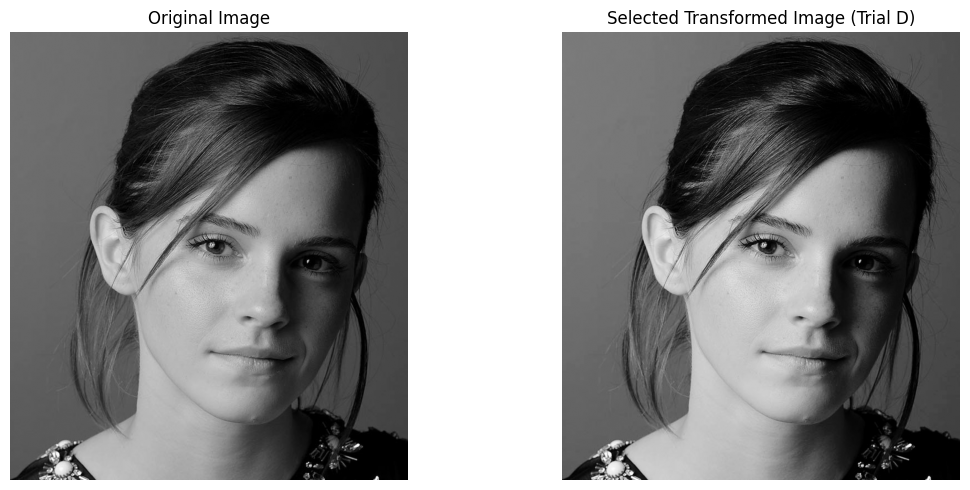

In [16]:
q1_final_figure, q1_final_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Original image
q1_final_axes[0].imshow(
    q1_portrait_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[0].set_title("Original Image")
q1_final_axes[0].axis("off")


# Selected transformed image - Trial D
q1_final_axes[1].imshow(
    q1_selected_output,
    cmap="gray",
    vmin=0,
    vmax=255
)

q1_final_axes[1].set_title("Selected Transformed Image (Trial D)")
q1_final_axes[1].axis("off")

plt.tight_layout()
plt.show()

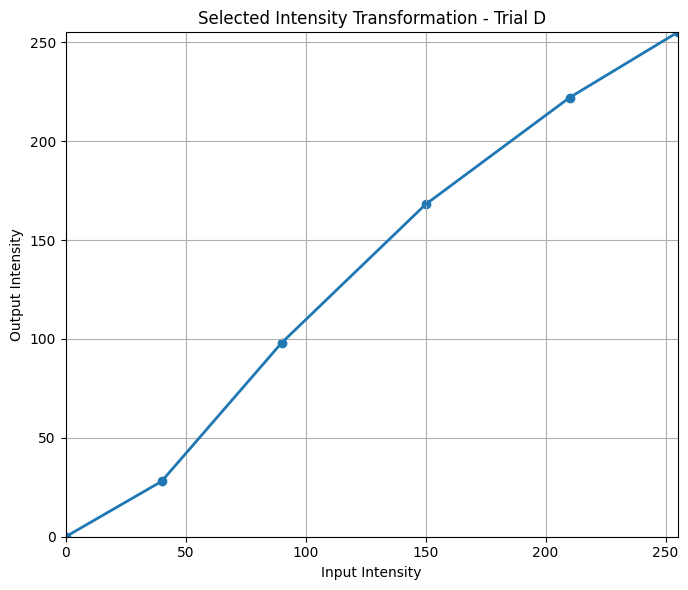

In [17]:
q1_selected_intensity_axis = np.arange(256)

q1_selected_mapping = np.interp(
    q1_selected_intensity_axis,
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.figure(figsize=(7, 6))

plt.plot(
    q1_selected_intensity_axis,
    q1_selected_mapping,
    linewidth=2
)

plt.scatter(
    q1_selected_breakpoints[:, 0],
    q1_selected_breakpoints[:, 1]
)

plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.title("Selected Intensity Transformation - Trial D")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

## Question 2 - White Matter and Gray Matter Enhancement

Piecewise linear intensity transformations are used to separately accentuate white matter and gray matter in the proton-density brain image.

The image intensity distribution is first examined to identify suitable intensity ranges for the two tissue types. Separate transformations are then designed for white matter and gray matter enhancement.

In [18]:
q2_brain_file = IMAGE_DIR / "q2.jpeg"

q2_brain_gray = cv.imread(
    str(q2_brain_file),
    cv.IMREAD_GRAYSCALE
)

if q2_brain_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 2 image: {q2_brain_file}"
    )

print("Brain image shape:", q2_brain_gray.shape)
print("Brain image datatype:", q2_brain_gray.dtype)
print("Minimum intensity:", q2_brain_gray.min())
print("Maximum intensity:", q2_brain_gray.max())

Brain image shape: (217, 181)
Brain image datatype: uint8
Minimum intensity: 0
Maximum intensity: 251


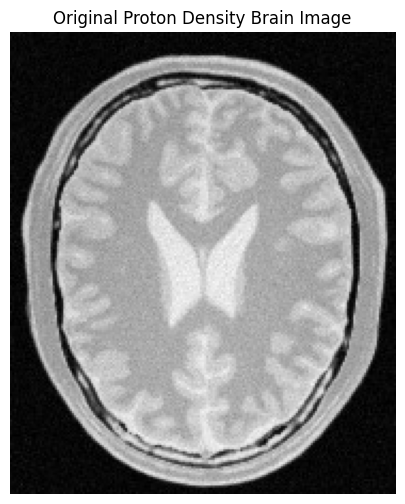

In [19]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q2_brain_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Proton Density Brain Image")
plt.axis("off")

plt.show()

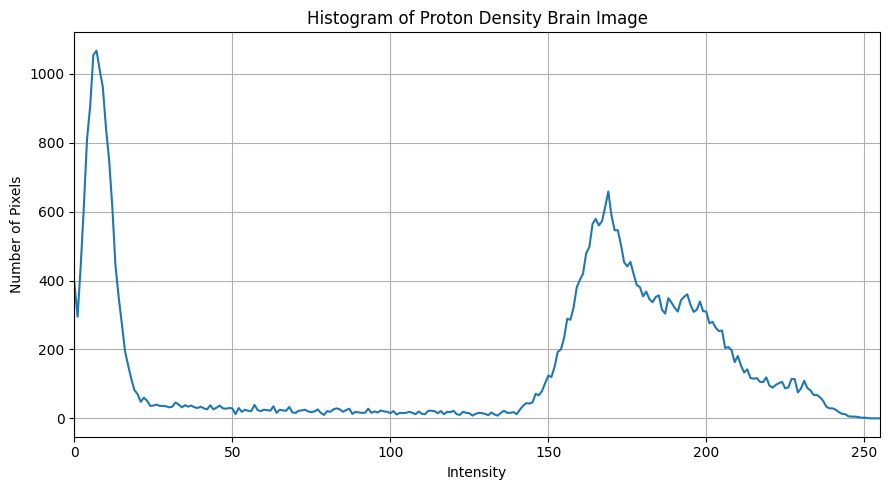

In [20]:
q2_histogram_counts, q2_histogram_bins = np.histogram(
    q2_brain_gray.flatten(),
    bins=256,
    range=(0, 256)
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_histogram_counts
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Histogram of Proton Density Brain Image")

plt.xlim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

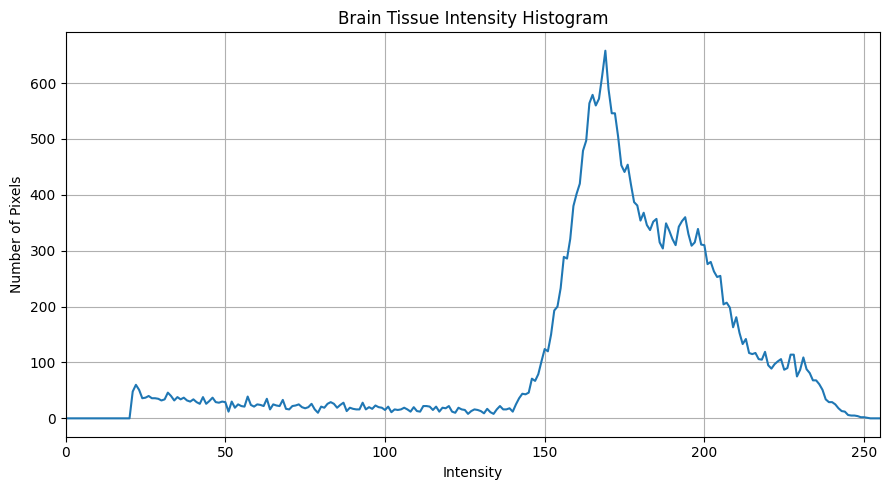

In [21]:
q2_tissue_pixels = q2_brain_gray[q2_brain_gray > 20]

q2_tissue_histogram, _ = np.histogram(
    q2_tissue_pixels,
    bins=256,
    range=(0, 256)
)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_tissue_histogram
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Tissue Intensity Histogram")

plt.xlim(0, 255)
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
q2_percentile_levels = [5, 10, 25, 50, 75, 90, 95]

q2_tissue_percentiles = np.percentile(
    q2_tissue_pixels,
    q2_percentile_levels
)

for q2_percentile_label, q2_percentile_value in zip(
    q2_percentile_levels,
    q2_tissue_percentiles
):
    print(
        f"{q2_percentile_label:>2}th percentile: "
        f"{q2_percentile_value:.2f}"
    )

 5th percentile: 64.00
10th percentile: 141.00
25th percentile: 163.00
50th percentile: 175.00
75th percentile: 195.00
90th percentile: 211.00
95th percentile: 223.00


In [30]:
# Final piecewise-linear transformation for white matter enhancement
q2_white_matter_breakpoints = np.array([
    [0,   0],
    [120, 105],
    [145, 125],
    [160, 145],
    [180, 200],
    [200, 218],
    [225, 238],
    [255, 255]
], dtype=np.float32)


# Final piecewise-linear transformation for gray matter enhancement
q2_gray_matter_breakpoints = np.array([
    [0,   0],
    [135, 115],
    [165, 140],
    [185, 165],
    [205, 220],
    [225, 238],
    [255, 255]
], dtype=np.float32)

In [31]:
q2_white_matter_output = intensity_transform(
    q2_brain_gray,
    q2_white_matter_breakpoints
)

q2_gray_matter_output = intensity_transform(
    q2_brain_gray,
    q2_gray_matter_breakpoints
)

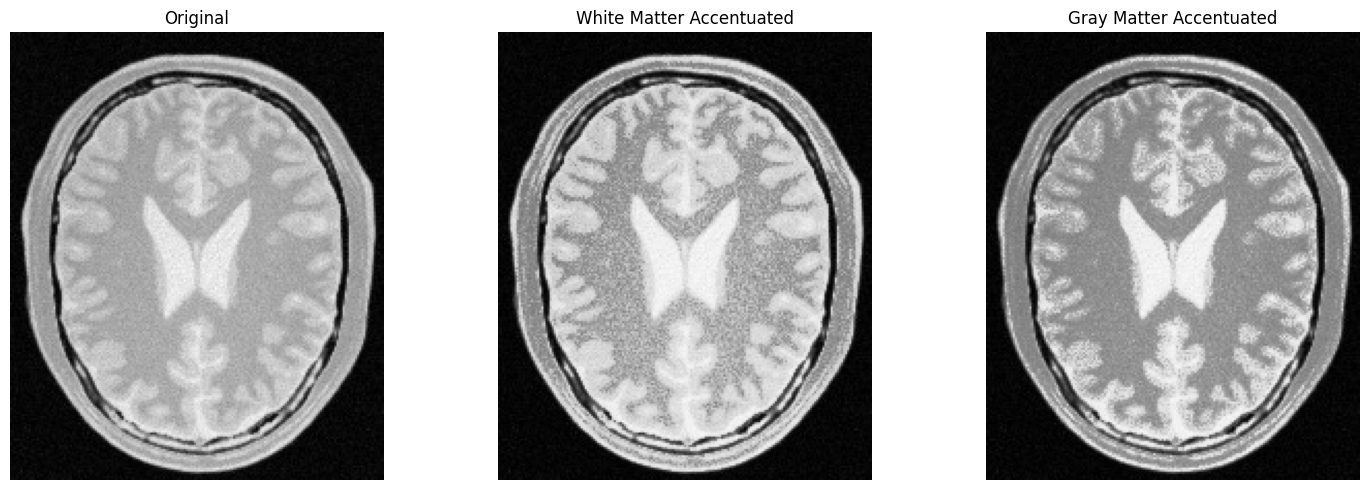

In [32]:
q2_final_figure, q2_final_axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

q2_final_images = [
    q2_brain_gray,
    q2_white_matter_output,
    q2_gray_matter_output
]

q2_final_titles = [
    "Original",
    "White Matter Accentuated",
    "Gray Matter Accentuated"
]

for q2_final_index in range(3):

    q2_final_axes[q2_final_index].imshow(
        q2_final_images[q2_final_index],
        cmap="gray",
        vmin=0,
        vmax=255
    )

    q2_final_axes[q2_final_index].set_title(
        q2_final_titles[q2_final_index]
    )

    q2_final_axes[q2_final_index].axis("off")

plt.tight_layout()
plt.show()

In [33]:
q2_intensity_axis = np.arange(256)

q2_white_matter_curve = np.interp(
    q2_intensity_axis,
    q2_white_matter_breakpoints[:, 0],
    q2_white_matter_breakpoints[:, 1]
)

q2_gray_matter_curve = np.interp(
    q2_intensity_axis,
    q2_gray_matter_breakpoints[:, 0],
    q2_gray_matter_breakpoints[:, 1]
)

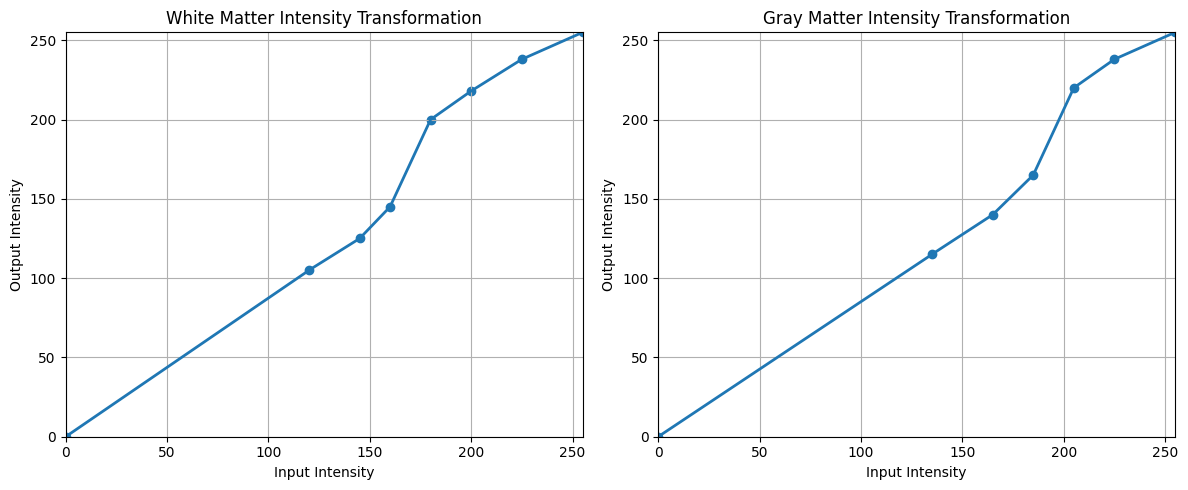

In [34]:
q2_transform_figure, q2_transform_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# White matter transformation
q2_transform_axes[0].plot(
    q2_intensity_axis,
    q2_white_matter_curve,
    linewidth=2
)

q2_transform_axes[0].scatter(
    q2_white_matter_breakpoints[:, 0],
    q2_white_matter_breakpoints[:, 1]
)

q2_transform_axes[0].set_title(
    "White Matter Intensity Transformation"
)

q2_transform_axes[0].set_xlabel("Input Intensity")
q2_transform_axes[0].set_ylabel("Output Intensity")

q2_transform_axes[0].set_xlim(0, 255)
q2_transform_axes[0].set_ylim(0, 255)
q2_transform_axes[0].grid(True)


# Gray matter transformation
q2_transform_axes[1].plot(
    q2_intensity_axis,
    q2_gray_matter_curve,
    linewidth=2
)

q2_transform_axes[1].scatter(
    q2_gray_matter_breakpoints[:, 0],
    q2_gray_matter_breakpoints[:, 1]
)

q2_transform_axes[1].set_title(
    "Gray Matter Intensity Transformation"
)

q2_transform_axes[1].set_xlabel("Input Intensity")
q2_transform_axes[1].set_ylabel("Output Intensity")

q2_transform_axes[1].set_xlim(0, 255)
q2_transform_axes[1].set_ylim(0, 255)
q2_transform_axes[1].grid(True)


plt.tight_layout()
plt.show()

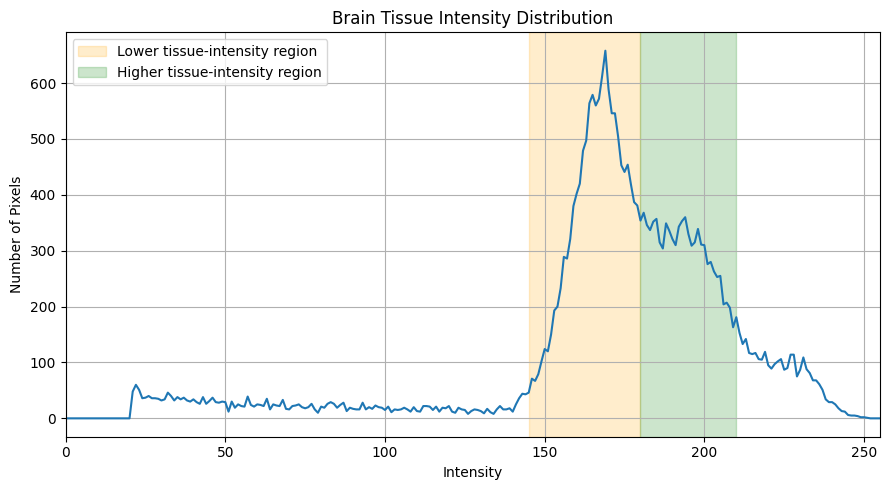

In [36]:
plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(256),
    q2_tissue_histogram,
    linewidth=1.5
)

# Lower tissue-intensity region
plt.axvspan(
    145,
    180,
    alpha=0.20,
    color="orange",
    label="Lower tissue-intensity region"
)

# Higher tissue-intensity region
plt.axvspan(
    180,
    210,
    alpha=0.20,
    color="green",
    label="Higher tissue-intensity region"
)

plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Tissue Intensity Distribution")

plt.xlim(0, 255)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Discussion

The histogram shows that most of the relevant brain-tissue intensities are concentrated approximately within the mid-to-high intensity range. Two intensity regions were therefore selected from the histogram to guide the design of the transformations.

Two separate piecewise-linear intensity transformations were designed. The first increases the contrast predominantly within the lower selected tissue-intensity range, with the aim of accentuating white matter. The second places stronger contrast enhancement within the higher selected tissue-intensity range, with the aim of accentuating gray matter. These intensity ranges are used as approximate enhancement regions rather than strict tissue-segmentation boundaries.

The transformations were kept gradual outside the selected ranges in order to preserve the overall anatomical appearance of the proton-density image and avoid excessive saturation caused by stronger contrast mappings.

## Question 3 - Gamma Correction

Gamma correction is applied to the lightness (L) channel of the image in the L*a*b* color space. Different gamma values are tested and a suitable value is selected based on the resulting image.

The histograms of the original and gamma-corrected images are then compared.

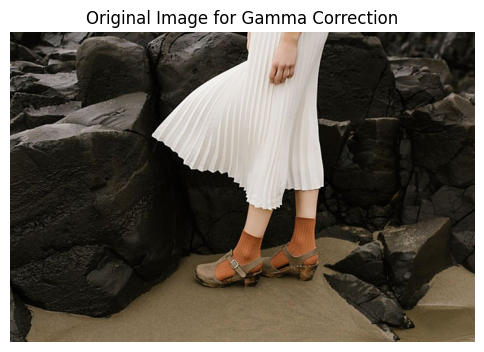

In [38]:
q3_image_path = IMAGE_DIR / "q3.jpeg"

q3_image_bgr = cv.imread(str(q3_image_path))

if q3_image_bgr is None:
    raise FileNotFoundError(f"Could not load: {q3_image_path}")

q3_image_rgb = cv.cvtColor(
    q3_image_bgr,
    cv.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))
plt.imshow(q3_image_rgb)
plt.title("Original Image for Gamma Correction")
plt.axis("off")
plt.show()

In [39]:
q3_image_lab = cv.cvtColor(
    q3_image_bgr,
    cv.COLOR_BGR2LAB
)

q3_lightness_channel, q3_a_channel, q3_b_channel = cv.split(
    q3_image_lab
)

print("L channel shape:", q3_lightness_channel.shape)
print("L channel range:",
      q3_lightness_channel.min(),
      "to",
      q3_lightness_channel.max())

L channel shape: (480, 720)
L channel range: 0 to 255


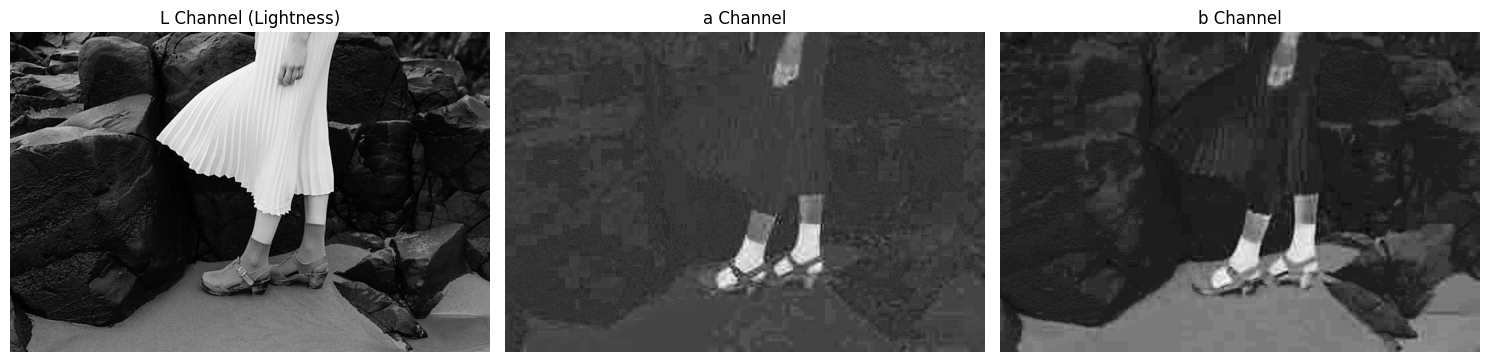

In [40]:
q3_lab_figure, q3_lab_axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

q3_lab_channels = [
    q3_lightness_channel,
    q3_a_channel,
    q3_b_channel
]

q3_lab_titles = [
    "L Channel (Lightness)",
    "a Channel",
    "b Channel"
]

for q3_channel_index in range(3):

    q3_lab_axes[q3_channel_index].imshow(
        q3_lab_channels[q3_channel_index],
        cmap="gray"
    )

    q3_lab_axes[q3_channel_index].set_title(
        q3_lab_titles[q3_channel_index]
    )

    q3_lab_axes[q3_channel_index].axis("off")

plt.tight_layout()
plt.show()

In [42]:
def q3_gamma_correct_lightness(q3_lightness_input, q3_gamma_value):

    q3_normalized_lightness = (
        q3_lightness_input.astype(np.float32) / 255.0
    )

    q3_gamma_corrected_normalized = np.power(
        q3_normalized_lightness,
        q3_gamma_value
    )

    q3_gamma_corrected_lightness = np.clip(
        q3_gamma_corrected_normalized * 255.0,
        0,
        255
    )

    return q3_gamma_corrected_lightness.astype(np.uint8)

In [43]:
q3_gamma_candidates = [
    0.5,
    0.7,
    0.85,
    1.0
]

q3_gamma_outputs_rgb = []

for q3_gamma_candidate in q3_gamma_candidates:

    q3_corrected_lightness = q3_gamma_correct_lightness(
        q3_lightness_channel,
        q3_gamma_candidate
    )

    q3_corrected_lab = cv.merge([
        q3_corrected_lightness,
        q3_a_channel,
        q3_b_channel
    ])

    q3_corrected_bgr = cv.cvtColor(
        q3_corrected_lab,
        cv.COLOR_LAB2BGR
    )

    q3_corrected_rgb = cv.cvtColor(
        q3_corrected_bgr,
        cv.COLOR_BGR2RGB
    )

    q3_gamma_outputs_rgb.append(
        q3_corrected_rgb
    )

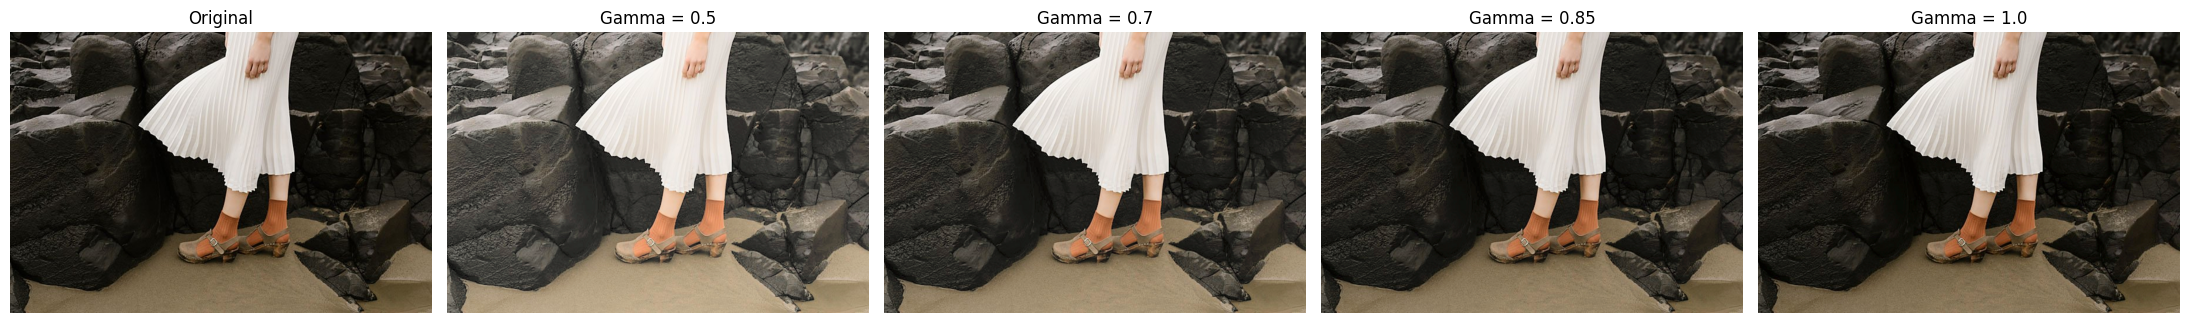

In [44]:
q3_gamma_figure, q3_gamma_axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

# Original
q3_gamma_axes[0].imshow(
    q3_image_rgb
)

q3_gamma_axes[0].set_title(
    "Original"
)

q3_gamma_axes[0].axis("off")


# Gamma-corrected versions
for q3_gamma_index, q3_gamma_candidate in enumerate(
    q3_gamma_candidates
):

    q3_gamma_axes[q3_gamma_index + 1].imshow(
        q3_gamma_outputs_rgb[q3_gamma_index]
    )

    q3_gamma_axes[q3_gamma_index + 1].set_title(
        f"Gamma = {q3_gamma_candidate}"
    )

    q3_gamma_axes[q3_gamma_index + 1].axis("off")


plt.tight_layout()
plt.show()

In [45]:
q3_selected_gamma = 0.85

q3_selected_lightness = q3_gamma_correct_lightness(
    q3_lightness_channel,
    q3_selected_gamma
)

q3_selected_lab = cv.merge([
    q3_selected_lightness,
    q3_a_channel,
    q3_b_channel
])

q3_selected_bgr = cv.cvtColor(
    q3_selected_lab,
    cv.COLOR_LAB2BGR
)

q3_selected_rgb = cv.cvtColor(
    q3_selected_bgr,
    cv.COLOR_BGR2RGB
)

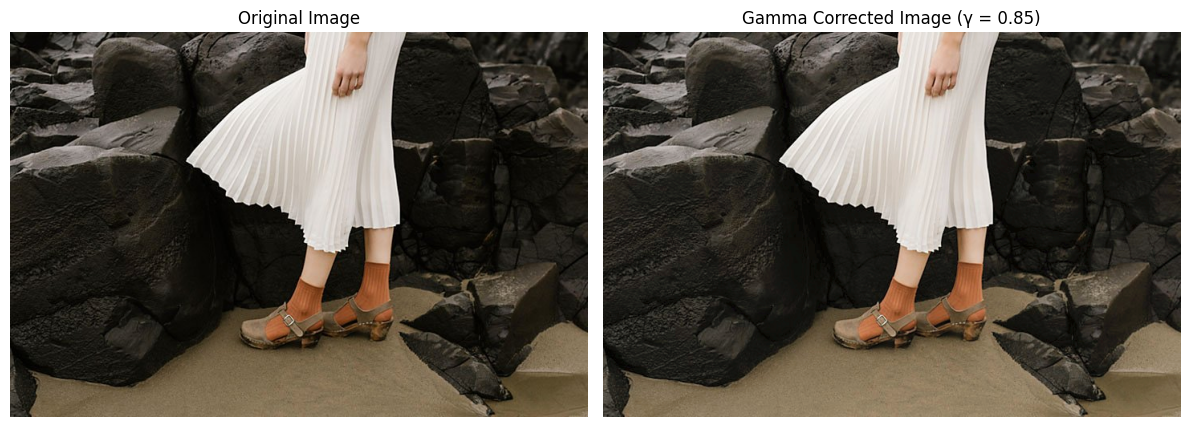

In [46]:
q3_final_figure, q3_final_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

q3_final_axes[0].imshow(q3_image_rgb)
q3_final_axes[0].set_title("Original Image")
q3_final_axes[0].axis("off")

q3_final_axes[1].imshow(q3_selected_rgb)
q3_final_axes[1].set_title(
    f"Gamma Corrected Image (γ = {q3_selected_gamma})"
)
q3_final_axes[1].axis("off")

plt.tight_layout()
plt.show()

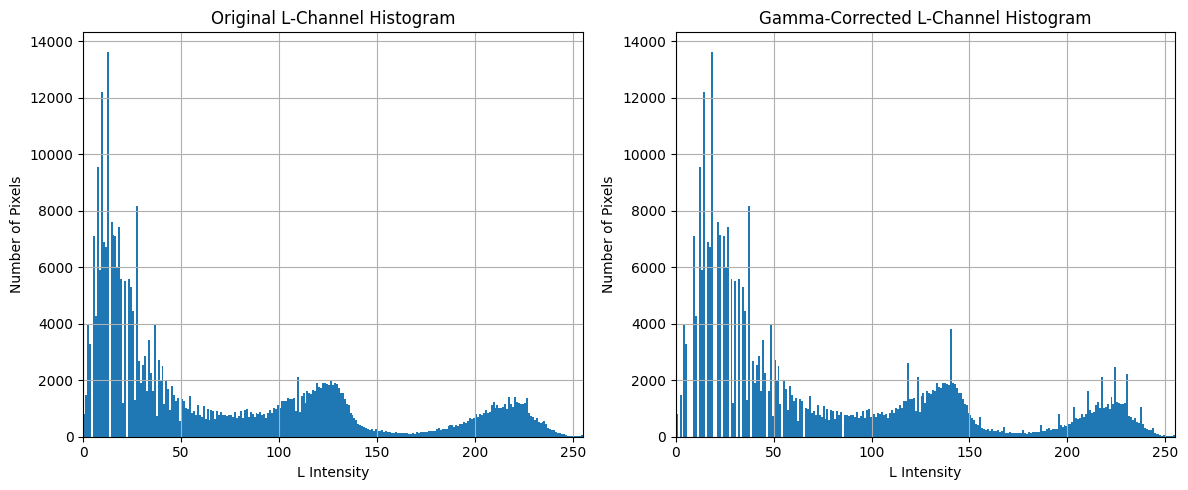

In [47]:
q3_histogram_figure, q3_histogram_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Original L-channel histogram
q3_histogram_axes[0].hist(
    q3_lightness_channel.ravel(),
    bins=256,
    range=(0, 256)
)

q3_histogram_axes[0].set_title(
    "Original L-Channel Histogram"
)
q3_histogram_axes[0].set_xlabel("L Intensity")
q3_histogram_axes[0].set_ylabel("Number of Pixels")
q3_histogram_axes[0].set_xlim(0, 255)
q3_histogram_axes[0].grid(True)


# Gamma-corrected L-channel histogram
q3_histogram_axes[1].hist(
    q3_selected_lightness.ravel(),
    bins=256,
    range=(0, 256)
)

q3_histogram_axes[1].set_title(
    "Gamma-Corrected L-Channel Histogram"
)
q3_histogram_axes[1].set_xlabel("L Intensity")
q3_histogram_axes[1].set_ylabel("Number of Pixels")
q3_histogram_axes[1].set_xlim(0, 255)
q3_histogram_axes[1].grid(True)


plt.tight_layout()
plt.show()

### Discussion

Gamma correction was applied only to the L channel of the L*a*b* representation so that the image lightness could be adjusted while largely preserving the chromatic information contained in the a and b channels.

Several gamma values were tested. A value of γ = 0.85 was selected because it moderately brightened the darker regions and revealed additional shadow detail while maintaining a natural overall appearance. Lower gamma values such as 0.5 and 0.7 produced stronger brightening and a more washed-out appearance.

The histogram of the corrected L channel is shifted toward higher intensity values compared with the original histogram. This is consistent with the gamma transformation for γ < 1, which maps darker and mid-level intensities to brighter output values.

## Question 4 - Vibrance Enhancement

The image is converted to the HSV color space and the saturation channel is modified using the nonlinear transformation specified in the assignment.

Different values of the parameter \(a\) are tested, and the value producing the most visually pleasing enhancement is selected.

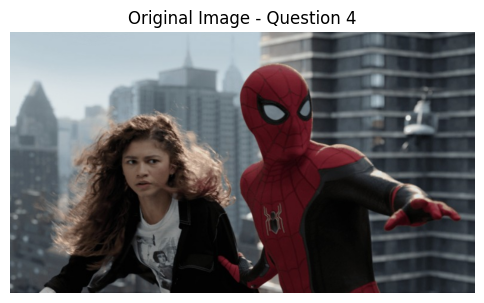

In [48]:
q4_image_path = IMAGE_DIR / "q4.jpeg"

q4_image_bgr = cv.imread(str(q4_image_path))

if q4_image_bgr is None:
    raise FileNotFoundError(
        f"Could not load Question 4 image: {q4_image_path}"
    )

q4_image_rgb = cv.cvtColor(
    q4_image_bgr,
    cv.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))
plt.imshow(q4_image_rgb)
plt.title("Original Image - Question 4")
plt.axis("off")
plt.show()

In [49]:
q4_image_hsv = cv.cvtColor(
    q4_image_bgr,
    cv.COLOR_BGR2HSV
)

q4_hue_channel, q4_saturation_channel, q4_value_channel = cv.split(
    q4_image_hsv
)

print("Hue range:",
      q4_hue_channel.min(),
      "to",
      q4_hue_channel.max())

print("Saturation range:",
      q4_saturation_channel.min(),
      "to",
      q4_saturation_channel.max())

print("Value range:",
      q4_value_channel.min(),
      "to",
      q4_value_channel.max())

Hue range: 0 to 179
Saturation range: 0 to 255
Value range: 0 to 238


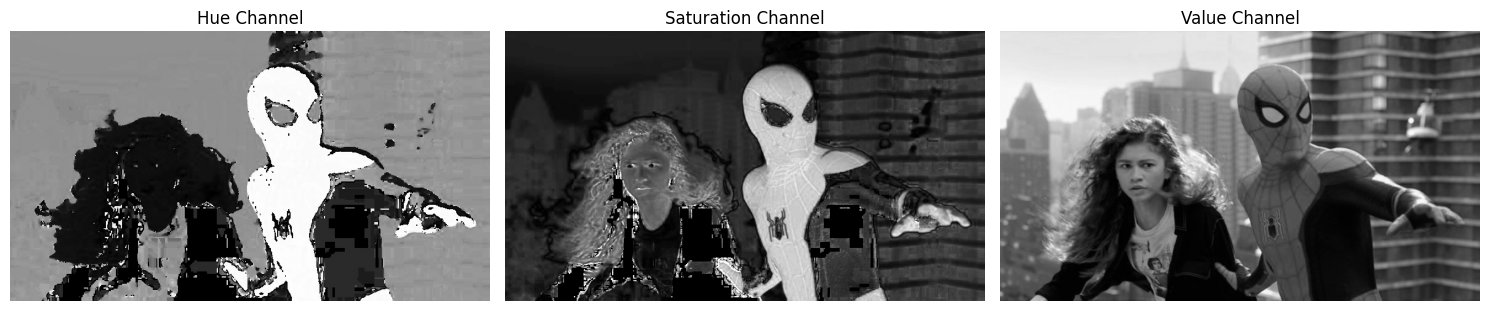

In [52]:
q4_hsv_figure, q4_hsv_axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

q4_hsv_channels = [
    q4_hue_channel,
    q4_saturation_channel,
    q4_value_channel
]

q4_hsv_titles = [
    "Hue Channel",
    "Saturation Channel",
    "Value Channel"
]

for q4_channel_index in range(3):

    q4_hsv_axes[q4_channel_index].imshow(
        q4_hsv_channels[q4_channel_index],
        cmap="gray"
    )

    q4_hsv_axes[q4_channel_index].set_title(
        q4_hsv_titles[q4_channel_index]
    )

    q4_hsv_axes[q4_channel_index].axis("off")

plt.tight_layout()
plt.show()

In [53]:
def q4_apply_vibrance(q4_saturation_input, q4_a_value, q4_sigma_value=70):

    q4_saturation_float = q4_saturation_input.astype(np.float32)

    q4_vibrance_boost = (
        q4_a_value
        * 128.0
        * np.exp(
            -((q4_saturation_float - 128.0) ** 2)
            / (2.0 * (q4_sigma_value ** 2))
        )
    )

    q4_enhanced_saturation = np.minimum(
        q4_saturation_float + q4_vibrance_boost,
        255.0
    )

    return q4_enhanced_saturation.astype(np.uint8)

Testing for multiple values of a


In [55]:
q4_a_candidates = [
    0.25,
    0.50,
    0.75,
    1.00
]

q4_vibrance_outputs_rgb = []

for q4_a_candidate in q4_a_candidates:

    q4_corrected_saturation = q4_apply_vibrance(
        q4_saturation_channel,
        q4_a_candidate
    )

    q4_corrected_hsv = cv.merge([
        q4_hue_channel,
        q4_corrected_saturation,
        q4_value_channel
    ])

    q4_corrected_bgr = cv.cvtColor(
        q4_corrected_hsv,
        cv.COLOR_HSV2BGR
    )

    q4_corrected_rgb = cv.cvtColor(
        q4_corrected_bgr,
        cv.COLOR_BGR2RGB
    )

    q4_vibrance_outputs_rgb.append(
        q4_corrected_rgb
    )

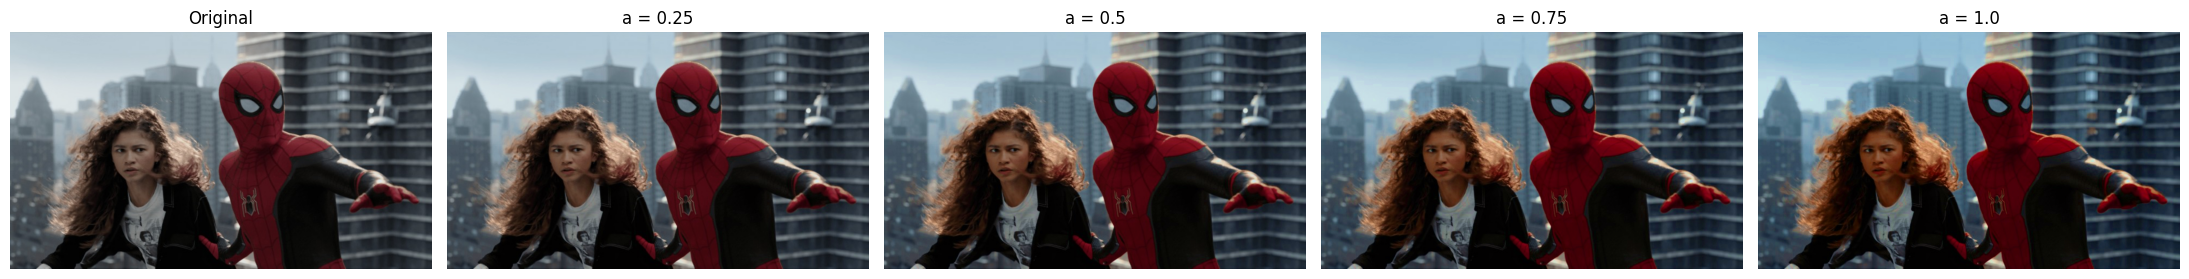

In [56]:
q4_compare_figure, q4_compare_axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

q4_compare_axes[0].imshow(
    q4_image_rgb
)

q4_compare_axes[0].set_title(
    "Original"
)

q4_compare_axes[0].axis("off")


for q4_candidate_index, q4_a_candidate in enumerate(
    q4_a_candidates
):

    q4_compare_axes[q4_candidate_index + 1].imshow(
        q4_vibrance_outputs_rgb[q4_candidate_index]
    )

    q4_compare_axes[q4_candidate_index + 1].set_title(
        f"a = {q4_a_candidate}"
    )

    q4_compare_axes[q4_candidate_index + 1].axis("off")


plt.tight_layout()
plt.show()

In [57]:
q4_selected_a = 0.50

q4_selected_saturation = q4_apply_vibrance(
    q4_saturation_channel,
    q4_selected_a
)

q4_selected_hsv = cv.merge([
    q4_hue_channel,
    q4_selected_saturation,
    q4_value_channel
])

q4_selected_bgr = cv.cvtColor(
    q4_selected_hsv,
    cv.COLOR_HSV2BGR
)

q4_selected_rgb = cv.cvtColor(
    q4_selected_bgr,
    cv.COLOR_BGR2RGB
)

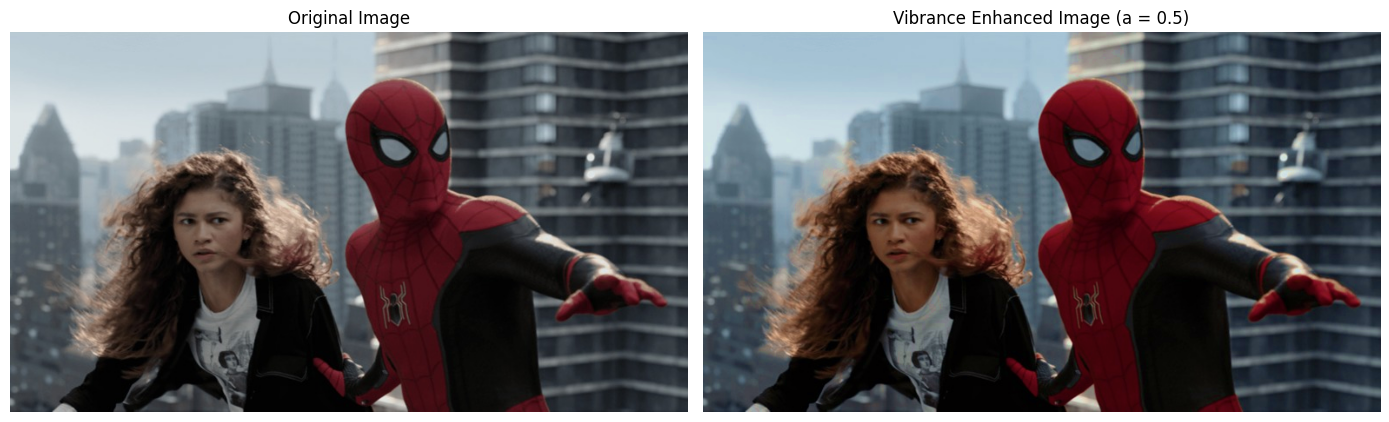

In [58]:
q4_final_figure, q4_final_axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

q4_final_axes[0].imshow(q4_image_rgb)
q4_final_axes[0].set_title("Original Image")
q4_final_axes[0].axis("off")

q4_final_axes[1].imshow(q4_selected_rgb)
q4_final_axes[1].set_title(
    f"Vibrance Enhanced Image (a = {q4_selected_a})"
)
q4_final_axes[1].axis("off")

plt.tight_layout()
plt.show()

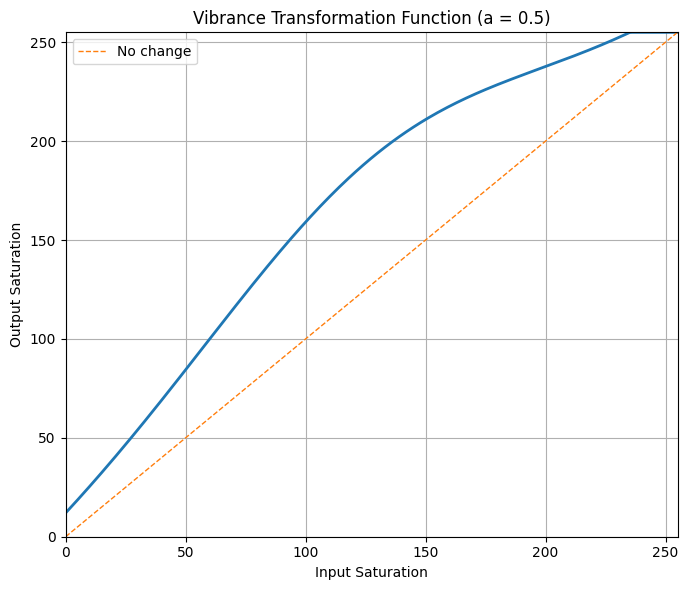

In [59]:
q4_intensity_axis = np.arange(256, dtype=np.float32)

q4_transformation_curve = np.minimum(
    q4_intensity_axis
    + q4_selected_a * 128.0
    * np.exp(
        -((q4_intensity_axis - 128.0) ** 2)
        / (2.0 * 70.0 ** 2)
    ),
    255.0
)

plt.figure(figsize=(7, 6))

plt.plot(
    q4_intensity_axis,
    q4_transformation_curve,
    linewidth=2
)

plt.plot(
    [0, 255],
    [0, 255],
    "--",
    linewidth=1,
    label="No change"
)

plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(
    f"Vibrance Transformation Function (a = {q4_selected_a})"
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Question 5 - Histogram Equalization

Histogram equalization is implemented manually using the image histogram and cumulative distribution function (CDF).

The original and equalized images are compared together with their corresponding histograms.

In [60]:
q5_image_path = IMAGE_DIR / "q5.jpeg"

q5_image_gray = cv.imread(
    str(q5_image_path),
    cv.IMREAD_GRAYSCALE
)

if q5_image_gray is None:
    raise FileNotFoundError(
        f"Could not load Question 5 image: {q5_image_path}"
    )

print("Image shape:", q5_image_gray.shape)
print("Image datatype:", q5_image_gray.dtype)
print("Minimum intensity:", q5_image_gray.min())
print("Maximum intensity:", q5_image_gray.max())

Image shape: (500, 500)
Image datatype: uint8
Minimum intensity: 13
Maximum intensity: 83


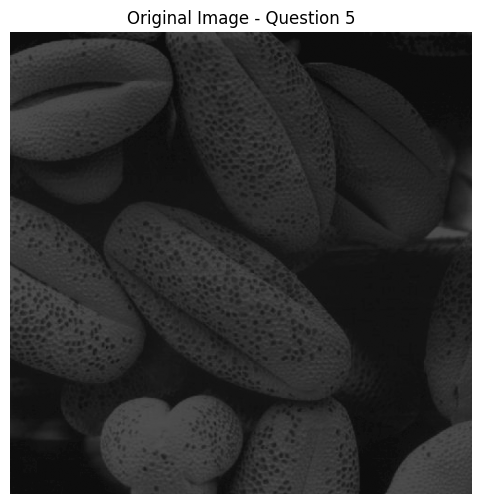

In [61]:
plt.figure(figsize=(6, 6))

plt.imshow(
    q5_image_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Original Image - Question 5")
plt.axis("off")

plt.show()

In [62]:
def q5_histogram_equalize(q5_input_image):

    q5_histogram = np.bincount(
        q5_input_image.ravel(),
        minlength=256
    )

    q5_probability_distribution = (
        q5_histogram / q5_input_image.size
    )

    q5_cdf = np.cumsum(
        q5_probability_distribution
    )

    q5_mapping = np.floor(
        255 * q5_cdf
    ).astype(np.uint8)

    q5_equalized_image = q5_mapping[
        q5_input_image
    ]

    return (
        q5_equalized_image,
        q5_histogram,
        q5_cdf,
        q5_mapping
    )

In [63]:
(
    q5_equalized_gray,
    q5_original_histogram,
    q5_original_cdf,
    q5_equalization_mapping
) = q5_histogram_equalize(
    q5_image_gray
)

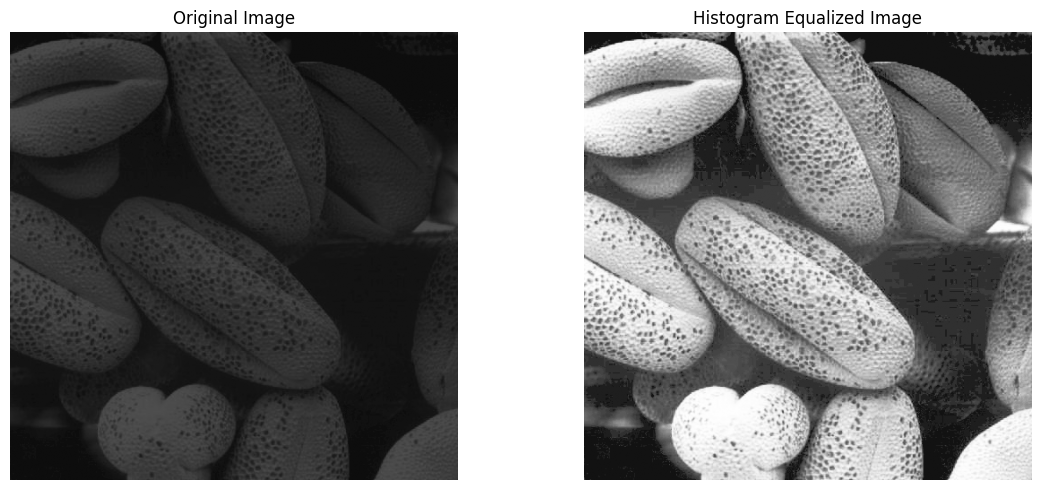

In [64]:
q5_image_figure, q5_image_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

q5_image_axes[0].imshow(
    q5_image_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)
q5_image_axes[0].set_title("Original Image")
q5_image_axes[0].axis("off")

q5_image_axes[1].imshow(
    q5_equalized_gray,
    cmap="gray",
    vmin=0,
    vmax=255
)
q5_image_axes[1].set_title("Histogram Equalized Image")
q5_image_axes[1].axis("off")

plt.tight_layout()
plt.show()

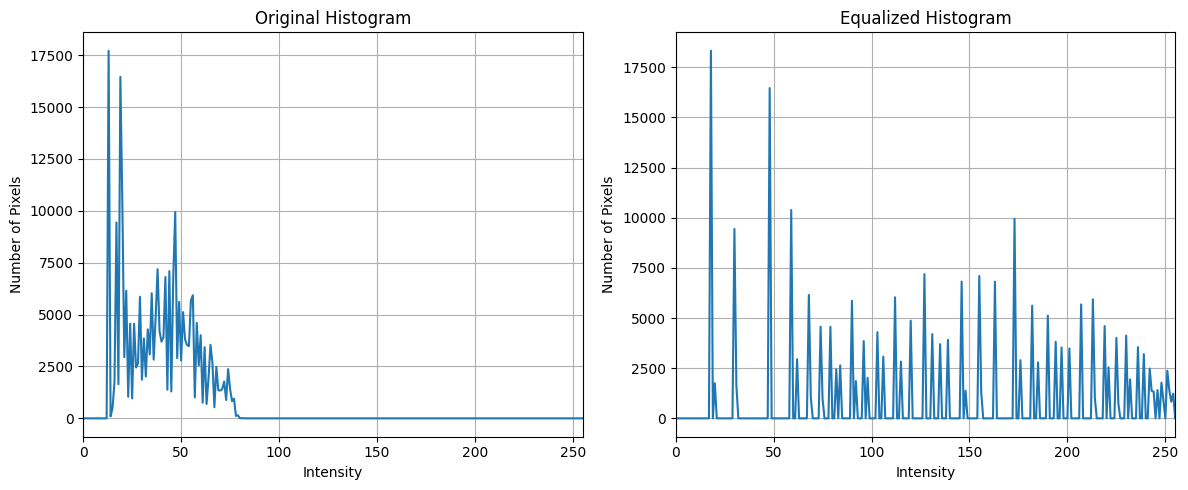

In [65]:
q5_equalized_histogram = np.bincount(
    q5_equalized_gray.ravel(),
    minlength=256
)

q5_histogram_figure, q5_histogram_axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

q5_histogram_axes[0].plot(
    np.arange(256),
    q5_original_histogram
)

q5_histogram_axes[0].set_title(
    "Original Histogram"
)
q5_histogram_axes[0].set_xlabel("Intensity")
q5_histogram_axes[0].set_ylabel("Number of Pixels")
q5_histogram_axes[0].set_xlim(0, 255)
q5_histogram_axes[0].grid(True)


q5_histogram_axes[1].plot(
    np.arange(256),
    q5_equalized_histogram
)

q5_histogram_axes[1].set_title(
    "Equalized Histogram"
)
q5_histogram_axes[1].set_xlabel("Intensity")
q5_histogram_axes[1].set_ylabel("Number of Pixels")
q5_histogram_axes[1].set_xlim(0, 255)
q5_histogram_axes[1].grid(True)


plt.tight_layout()
plt.show()

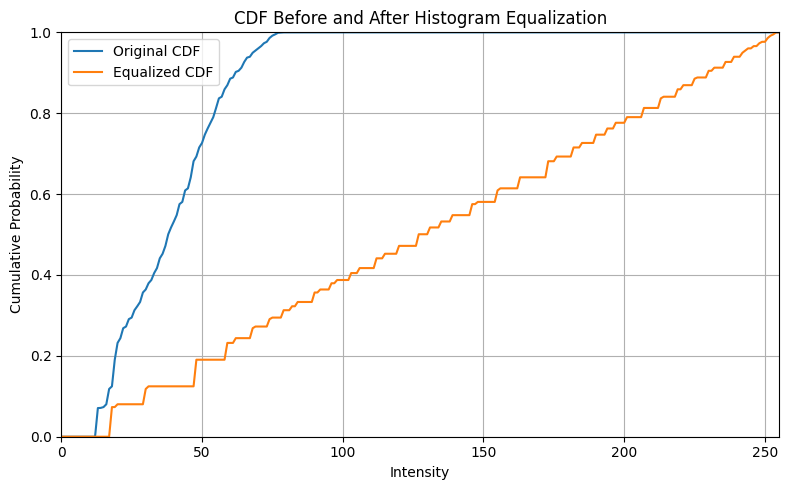

In [66]:
q5_equalized_probability = (
    q5_equalized_histogram / q5_equalized_gray.size
)

q5_equalized_cdf = np.cumsum(
    q5_equalized_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(256),
    q5_original_cdf,
    label="Original CDF"
)

plt.plot(
    np.arange(256),
    q5_equalized_cdf,
    label="Equalized CDF"
)

plt.xlabel("Intensity")
plt.ylabel("Cumulative Probability")
plt.title("CDF Before and After Histogram Equalization")

plt.xlim(0, 255)
plt.ylim(0, 1)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

The original image contains most of its pixel intensities within a relatively narrow low-intensity range, which results in poor global contrast.

Histogram equalization redistributes these intensity values over a much wider portion of the available 0–255 range. As a result, previously dark image details become more visible and the overall contrast is improved.

The equalized histogram is not perfectly uniform because the image contains a finite number of discrete intensity values. However, the corresponding CDF is distributed much more gradually across the full intensity range compared with the steep CDF of the original image.